# Calculating solar position in Python

This tutorial demonstrates how to calculate solar positions in Python using the [pvlib-python](https://pvlib-python.readthedocs.io/) library.


The first step is to import a few Python pacakges.

In [ ]:
# Install pvlib on Google Colab as this is not a standard package.
!pip install pvlib

In [1]:
import pvlib  # library for PV and solar calculations
import pandas as pd  # library for data analysis
import matplotlib.pyplot as plt  # library for plotting

## Step 1: Define a location

A location is defined by a latitude and longitude according to the convention of [ISO 6709](https://en.wikipedia.org/wiki/ISO_6709). Specifically, latitude is in degrees north of the equator and the longitude is in degrees east of the prime meridian.

In [7]:
latitude = 64.17
longitude = -51.73

## Step 2: Define time stamps

The next step is to define the time stamps for which you want to calculate solar positions for. Here it is important to specify the timezone as otherwise UTC will be assumed.

For more information on available timezones, see the [pvlib documentation on timezones](https://pvlib-python.readthedocs.io/en/stable/user_guide/modeling_topics/timetimezones.html).

In [6]:
times = pd.date_range(
    start='2025-08-02 00:00',
    end='2025-08-02 23:59',
    freq='1min',  # frequency
    tz='America/Nuuk',  # timezone
)

times

DatetimeIndex(['2025-08-02 00:00:00-01:00', '2025-08-02 00:01:00-01:00',
               '2025-08-02 00:02:00-01:00', '2025-08-02 00:03:00-01:00',
               '2025-08-02 00:04:00-01:00', '2025-08-02 00:05:00-01:00',
               '2025-08-02 00:06:00-01:00', '2025-08-02 00:07:00-01:00',
               '2025-08-02 00:08:00-01:00', '2025-08-02 00:09:00-01:00',
               ...
               '2025-08-02 23:50:00-01:00', '2025-08-02 23:51:00-01:00',
               '2025-08-02 23:52:00-01:00', '2025-08-02 23:53:00-01:00',
               '2025-08-02 23:54:00-01:00', '2025-08-02 23:55:00-01:00',
               '2025-08-02 23:56:00-01:00', '2025-08-02 23:57:00-01:00',
               '2025-08-02 23:58:00-01:00', '2025-08-02 23:59:00-01:00'],
              dtype='datetime64[ns, America/Nuuk]', length=1440, freq='min')

## Step 3: Calculate solar position

Once we have defined a location and the time stamps for which we want to calculate solar position for, we can use the function ``pvlib.solarposition.get_solarposition`` to calculate the solar positions:

In [11]:
solarposition = pvlib.solarposition.get_solarposition(times, latitude, longitude)

solarposition.head()  # Inspect the first 5 rows

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2025-08-02 00:00:00-01:00,92.951763,92.951763,-2.951763,-2.951763,323.755517,-6.314985
2025-08-02 00:01:00-01:00,93.016162,93.016162,-3.016162,-3.016162,323.985085,-6.314936
2025-08-02 00:02:00-01:00,93.080208,93.080208,-3.080208,-3.080208,324.214766,-6.314886
2025-08-02 00:03:00-01:00,93.143900,93.143900,-3.143900,-3.143900,324.444560,-6.314836
2025-08-02 00:04:00-01:00,93.207236,93.207236,-3.207236,-3.207236,324.674467,-6.314786


## Step 4: Plot the solar position

array([<Axes: >, <Axes: >], dtype=object)

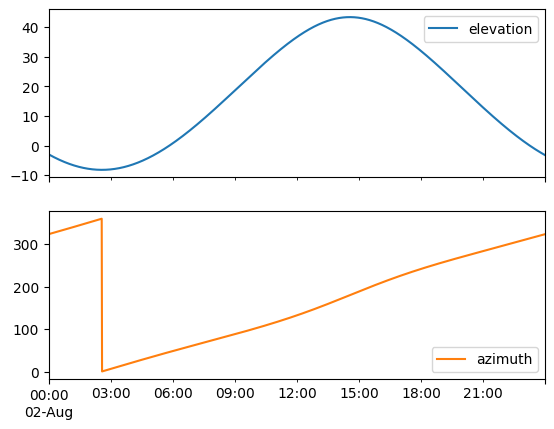

In [12]:
solarposition[['elevation', 'azimuth']].plot(
    subplots=True, sharex=True)

## Step 5: Determine the maximum solar elevation for Sisimiut

In this last final step, you need to determine the maximum solar elevation over the year for Sisimiut.

You can achieve this by modifying the calculations above and finding the maximum value of the ``solarposition["elevation"]``.

In [ ]:
# Write your code here
